This is to explore crypto dataset

# Cryptocurrency Price Prediction: Model Comparison and Interactive Visualization

This notebook demonstrates how to predict cryptocurrency prices using various regression models. The analysis includes:

1. Data loading and feature engineering
2. Training and comparing multiple models (LightGBM, XGBoost, Random Forest, Gradient Boosting, ElasticNet)
3. Analyzing model performance metrics and feature importance
4. Creating interactive visualizations for cryptocurrency price predictions with configurable symbols
5. Building an advanced dashboard with trading insights and error analysis

The goal is to identify the most effective model for cryptocurrency price prediction and visualize the results in an interactive manner.

In [1]:
!pip install lightgbm pandas numpy scikit-learn matplotlib optuna xgboost seaborn ipywidgets

You should consider upgrading via the '/Users/soumyadey/.pyenv/versions/3.10.0/bin/python3.10 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/soumyadey/.pyenv/versions/3.10.0/bin/python3.10 -m pip install --upgrade pip' command.


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
# Load and preview the data
df = pd.read_csv('../crypto-markets.csv', parse_dates=['date'])
df = df.sort_values('date')
df.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.300000,135.980000,132.100000,134.210000,0.0,1.488567e+09,0.5438,3.88
409999,terracoin,TRC,Terracoin,2013-04-28,895,0.650793,0.654064,0.634409,0.646892,0.0,1.503099e+06,0.6351,0.02
92607,peercoin,PPC,Peercoin,2013-04-28,159,0.386958,0.404659,0.376287,0.386525,0.0,7.250189e+06,0.3608,0.03
193471,namecoin,NMC,Namecoin,2013-04-28,371,1.100000,1.120000,1.080000,1.110000,0.0,5.995983e+06,0.7500,0.04
7787,litecoin,LTC,Litecoin,2013-04-28,7,4.300000,4.400000,4.180000,4.350000,0.0,7.463694e+07,0.7727,0.22


In [5]:
# Feature engineering
# Spread, return, moving averages, volatility, lag features, and target

# Daily Spread: High - Low
# Daily Return: (Close - Open) / Open
# Moving Averages: 3-day, 7-day, 14-day moving averages of Close
# Volatility: Rolling standard deviation of Close (e.g., 7-day window)
# Relative Strength Index (RSI): 14-day RSI
# Lag Features: Previous day’s Close, Volume, etc.

df['spread'] = df['high'] - df['low']
df['return'] = (df['close'] - df['open']) / df['open']
df['ma_3'] = df['close'].rolling(window=3).mean()
df['ma_7'] = df['close'].rolling(window=7).mean()
df['ma_14'] = df['close'].rolling(window=14).mean()
df['volatility_7'] = df['close'].rolling(window=7).std()
df['close_lag1'] = df['close'].shift(1)
df['volume_lag1'] = df['volume'].shift(1)

# Target: next day's close price
df['target'] = df['close'].shift(-1)

df = df.dropna()
df.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,...,close_ratio,spread,return,ma_3,ma_7,ma_14,volatility_7,close_lag1,volume_lag1,target
410001,terracoin,TRC,Terracoin,2013-04-30,895,0.707040,0.711892,0.647944,0.67415,0.0,...,0.4098,0.063948,-0.046518,1.16805,1.953243,21.654723,1.799602,1.50000,0.0,139.000000
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.000000,146.930000,134.050000,139.00000,0.0,...,0.3843,12.880000,-0.034722,47.05805,21.709002,21.996866,51.748862,0.67415,0.0,0.375300
92609,peercoin,PPC,Peercoin,2013-04-30,159,0.407066,0.436540,0.363140,0.37530,0.0,...,0.1657,0.073400,-0.078036,46.68315,21.095473,21.977466,52.009347,139.00000,0.0,4.310000
325299,novacoin,NVC,Novacoin,2013-04-30,700,4.560000,4.690000,4.200000,4.31000,0.0,...,0.2245,0.490000,-0.054825,47.89510,21.652779,22.257714,51.771091,0.37530,0.0,4.300000
7789,litecoin,LTC,Litecoin,2013-04-30,7,4.400000,4.570000,4.170000,4.30000,0.0,...,0.3250,0.400000,-0.022727,2.99510,21.641350,22.485572,51.775548,4.31000,0.0,0.568572


In [6]:
# Split data into train and test sets (time-based split)
features = ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']
X = df[features]
y = df['target']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 753826, Test size: 188457


In [7]:
# Train LightGBM quantile regression models
params_median = {'objective': 'quantile', 'alpha': 0.5, 'n_estimators': 100, 'random_state': 42}
params_lower = {'objective': 'quantile', 'alpha': 0.1, 'n_estimators': 100, 'random_state': 42}
params_upper = {'objective': 'quantile', 'alpha': 0.9, 'n_estimators': 100, 'random_state': 42}

model_median = lgb.LGBMRegressor(**params_median)
model_lower = lgb.LGBMRegressor(**params_lower)
model_upper = lgb.LGBMRegressor(**params_upper)

model_median.fit(X_train, y_train)
model_lower.fit(X_train, y_train)
model_upper.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 753826, number of used features: 13
[LightGBM] [Info] Start training from score 0.027108
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 753826, number of used features: 13
[LightGBM] [Info] Start training from score 0.000157
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'quantile'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Training and comparing multiple models to find the best one...

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 753826, number of used features: 13
[LightGBM] [Info] Start training from score 402.968118
  Train - MAE: $805.5367, RMSE: $13976.4438, R²: 0.0727
  Test  - MAE: $432.1390, RMSE: $3976.8532, R²: -0.0459

Training XGBoost...
  Train - MAE: $852.1702, RMSE: $11353.3830, R²: 0.3881
  Test  - MAE: $601.6130, RMSE: $5085.1362, R²: -0.7101

Training Gradient Boosting...
  Train - MAE: $769.4927, RMSE: $13873.4829, R²: 0.0863
  Test  - MAE: $436.2905, RMSE: $3990.9551, R²: -0.0533

Training ElasticNet...


/Users/soumyadey/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.940e+13, tolerance: 1.588e+10
  model = cd_fast.enet_coordinate_descent(
/var/folders/_k/ld7_h48122gctk13bctqqkk40000gn/T/ipykernel_90012/1969418695.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='Test MAE', data=results_df, palette='viridis')
/var/folders/_k/ld7_h48122gctk13bctqqkk40000gn/T/ipykernel_90012/1969418695.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

  Train - MAE: $790.5845, RMSE: $14514.1397, R²: 0.0000
  Test  - MAE: $514.4268, RMSE: $3899.0151, R²: -0.0054

Best Model: LightGBM
Test MAE: $432.1390
Test RMSE: $3976.8532
Test R²: -0.0459


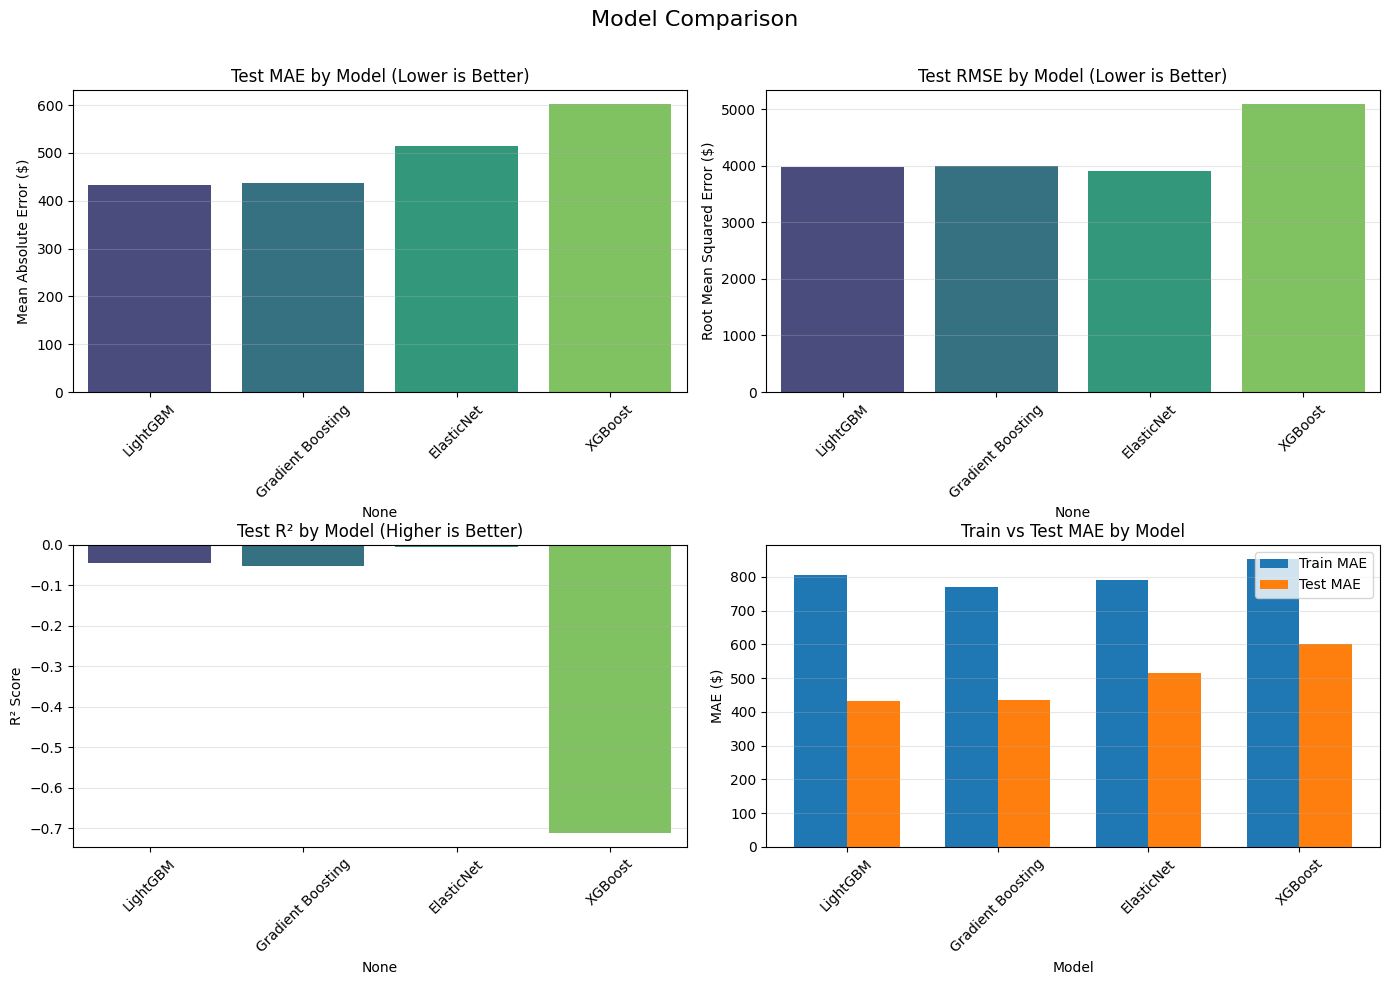

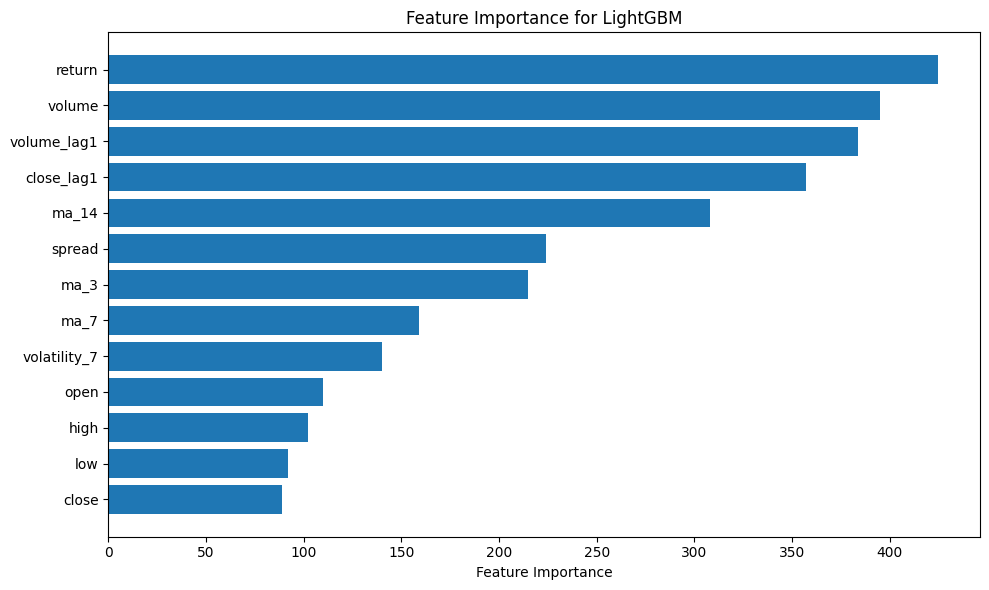

In [8]:
# Comprehensive Model Training and Comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.linear_model import ElasticNet

print("Training and comparing multiple models to find the best one...\n")

# Define models to compare
models = {
    'LightGBM': lgb.LGBMRegressor(objective='regression', random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100),
    # 'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100),
    'ElasticNet': ElasticNet(random_state=42, alpha=0.5, l1_ratio=0.5)
}

# Dictionary to store results
model_results = {}
trained_models = {}
predictions = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Make predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    predictions[name] = test_preds
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, train_preds)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_r2 = r2_score(y_train, train_preds)
    
    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_r2 = r2_score(y_test, test_preds)
    
    # Store results
    model_results[name] = {
        'Train MAE': train_mae,
        'Train RMSE': train_rmse,
        'Train R²': train_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test R²': test_r2
    }
    
    print(f"  Train - MAE: ${train_mae:.4f}, RMSE: ${train_rmse:.4f}, R²: {train_r2:.4f}")
    print(f"  Test  - MAE: ${test_mae:.4f}, RMSE: ${test_rmse:.4f}, R²: {test_r2:.4f}")
    print()

# Convert results to DataFrame for easier visualization
results_df = pd.DataFrame(model_results).T
results_df = results_df.sort_values('Test MAE')

# Find the best model based on Test MAE
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test MAE: ${results_df.loc[best_model_name, 'Test MAE']:.4f}")
print(f"Test RMSE: ${results_df.loc[best_model_name, 'Test RMSE']:.4f}")
print(f"Test R²: {results_df.loc[best_model_name, 'Test R²']:.4f}")

# Create visualization of model comparison
plt.figure(figsize=(14, 10))

# Plot 1: Test MAE comparison
plt.subplot(2, 2, 1)
sns.barplot(x=results_df.index, y='Test MAE', data=results_df, palette='viridis')
plt.title('Test MAE by Model (Lower is Better)', fontsize=12)
plt.ylabel('Mean Absolute Error ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Plot 2: Test RMSE comparison
plt.subplot(2, 2, 2)
sns.barplot(x=results_df.index, y='Test RMSE', data=results_df, palette='viridis')
plt.title('Test RMSE by Model (Lower is Better)', fontsize=12)
plt.ylabel('Root Mean Squared Error ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Plot 3: Test R² comparison
plt.subplot(2, 2, 3)
sns.barplot(x=results_df.index, y='Test R²', data=results_df, palette='viridis')
plt.title('Test R² by Model (Higher is Better)', fontsize=12)
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Plot 4: Train vs. Test MAE
plt.subplot(2, 2, 4)
train_mae = results_df['Train MAE'].values
test_mae = results_df['Test MAE'].values
model_names = results_df.index

x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, train_mae, width, label='Train MAE')
plt.bar(x + width/2, test_mae, width, label='Test MAE')
plt.xlabel('Model')
plt.ylabel('MAE ($)')
plt.title('Train vs Test MAE by Model')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Comparison', fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()

# Display feature importance for the best model if available
if best_model_name in ['LightGBM', 'XGBoost', 'Gradient Boosting']:
    plt.figure(figsize=(10, 6))
    
    # Get feature importance
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = best_model.feature_importances_
        sorted_idx = np.argsort(feature_importance)
        plt.barh(np.array(features)[sorted_idx], feature_importance[sorted_idx])
        plt.xlabel('Feature Importance')
        plt.title(f'Feature Importance for {best_model_name}')
        plt.tight_layout()
        plt.show()

In [19]:
# Save the best model to a pickle file for later reuse
import pickle
import os
import importlib
import sys

# Create a models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the best model to a pickle file
best_model_file = f'../models/{best_model_name}_best_model.pkl'
with open(best_model_file, 'wb') as f:
    pickle.dump(best_model, f)

# Create a comprehensive dependencies dictionary for functions needed in other cells
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython import display  # Import as a module, not a function

dependencies = {
    # Store the required functions directly
    'mean_absolute_error': mean_absolute_error,
    'mean_squared_error': mean_squared_error,
    'r2_score': r2_score,
    # Store imports info for other libraries
    'imports': {
        'pandas': 'pd',
        'numpy': 'np',
        'matplotlib.pyplot': 'plt',
        'seaborn': 'sns',
        'matplotlib.dates.DateFormatter': 'DateFormatter',
        'matplotlib.dates': 'mdates',
        'ipywidgets': 'widgets',
        'IPython.display': 'display',  # This will be imported as a module
        'pickle': 'pickle',
        'os': 'os'
    }
}

# Save model metadata to a separate file for easier reading
model_metadata = {
    'model_name': best_model_name,
    'features': features,
    'metrics': {
        'test_mae': float(results_df.loc[best_model_name, 'Test MAE']),
        'test_rmse': float(results_df.loc[best_model_name, 'Test RMSE']),
        'test_r2': float(results_df.loc[best_model_name, 'Test R²']),
    },
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    # Include comprehensive dependencies for other cells
    'dependencies': dependencies
}

with open('../models/model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print(f"Best model ({best_model_name}) saved to: {best_model_file}")
print(f"Model metadata and dependencies saved to: ../models/model_metadata.pkl")
print(f"Model features: {features}")
print(f"Required dependencies have been saved with the model metadata.")
print(f"Note: IPython.display is now correctly saved as a module, not a function.")

Best model (LightGBM) saved to: ../models/LightGBM_best_model.pkl
Model metadata and dependencies saved to: ../models/model_metadata.pkl
Model features: ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']
Required dependencies have been saved with the model metadata.
Note: IPython.display is now correctly saved as a module, not a function.


In [20]:
# Function to load the trained model from pickle file
import pickle
import os
import importlib
import sys

def load_best_model(force_reload=False):
    """
    Load the best trained model from the pickle file.
    If the model is already loaded in memory, it will return that unless force_reload=True.
    Also loads and makes available all required dependencies for predictions.
    
    Args:
        force_reload: If True, always reload the model from disk even if it's in memory
        
    Returns:
        model: The loaded model
        model_name: Name of the model
        model_metadata: Dictionary with model metadata
    """
    global best_model, best_model_name
    # Create references to the metrics functions in the global namespace
    global mean_absolute_error, mean_squared_error, r2_score
    
    # If the model is already loaded and we don't need to force reload, return it
    if 'best_model' in globals() and not force_reload:
        print(f"Using already loaded {best_model_name} model from memory")
        
        # Load metadata if available
        try:
            with open('../models/model_metadata.pkl', 'rb') as f:
                model_metadata = pickle.load(f)
                # Make sure dependencies are available
                if 'dependencies' in model_metadata:
                    # Import required metric functions
                    if 'mean_absolute_error' in model_metadata['dependencies']:
                        globals()['mean_absolute_error'] = model_metadata['dependencies']['mean_absolute_error']
                    if 'mean_squared_error' in model_metadata['dependencies']:
                        globals()['mean_squared_error'] = model_metadata['dependencies']['mean_squared_error']
                    if 'r2_score' in model_metadata['dependencies']:
                        globals()['r2_score'] = model_metadata['dependencies']['r2_score']
                    
                    # Import required libraries
                    if 'imports' in model_metadata['dependencies']:
                        for module_name, alias in model_metadata['dependencies']['imports'].items():
                            try:
                                # Special handling for IPython.display
                                if module_name == 'IPython.display':
                                    # Import correctly as a module
                                    from IPython import display
                                    globals()[alias] = display
                                elif module_name not in sys.modules:
                                    module = importlib.import_module(module_name)
                                    globals()[alias] = module
                                else:
                                    globals()[alias] = sys.modules[module_name]
                            except ImportError:
                                print(f"Warning: Could not import {module_name}")
        except Exception as e:
            print(f"Error loading dependencies: {e}")
            model_metadata = None
            
        return best_model, best_model_name, model_metadata
    
    # Otherwise, load from disk
    try:
        # Load metadata first to get the model name
        with open('../models/model_metadata.pkl', 'rb') as f:
            model_metadata = pickle.load(f)
            
        model_name = model_metadata['model_name']
        model_file = f'../models/{model_name}_best_model.pkl'
        
        # Load the actual model
        with open(model_file, 'rb') as f:
            model = pickle.load(f)
            
        print(f"Successfully loaded {model_name} model from {model_file}")
        print(f"Model was trained on: {model_metadata['date_trained']}")
        print(f"Test MAE: ${model_metadata['metrics']['test_mae']:.4f}")
        
        # Make dependencies available in the global namespace
        if 'dependencies' in model_metadata:
            # Load metric functions into the global namespace
            if 'mean_absolute_error' in model_metadata['dependencies']:
                globals()['mean_absolute_error'] = model_metadata['dependencies']['mean_absolute_error']
            if 'mean_squared_error' in model_metadata['dependencies']:
                globals()['mean_squared_error'] = model_metadata['dependencies']['mean_squared_error']
            if 'r2_score' in model_metadata['dependencies']:
                globals()['r2_score'] = model_metadata['dependencies']['r2_score']
            
            # Import required libraries
            if 'imports' in model_metadata['dependencies']:
                for module_name, alias in model_metadata['dependencies']['imports'].items():
                    try:
                        # Special handling for IPython.display
                        if module_name == 'IPython.display':
                            # Import correctly as a module
                            from IPython import display
                            globals()[alias] = display
                        elif module_name not in sys.modules:
                            module = importlib.import_module(module_name)
                            globals()[alias] = module
                        else:
                            globals()[alias] = sys.modules[module_name]
                    except ImportError:
                        print(f"Warning: Could not import {module_name}. You may need to install it with !pip install {module_name.split('.')[0]}")
        
        # Update global variables
        best_model = model
        best_model_name = model_name
        
        return model, model_name, model_metadata
    
    except Exception as e:
        print(f"Error loading model: {e}")
        print("Please train the model first or check if the model file exists.")
        return None, None, None

# Test the loading function
if os.path.exists('../models/model_metadata.pkl'):
    loaded_model, loaded_model_name, metadata = load_best_model()
    if loaded_model is not None:
        print(f"\nLoaded model features: {metadata['features']}")
        print("\nRequired dependencies have been loaded to the global namespace.")
        
        # Verify that critical functions are available
        if 'mean_absolute_error' in globals():
            print("✓ mean_absolute_error is available")
        if 'mean_squared_error' in globals():
            print("✓ mean_squared_error is available")
        if 'r2_score' in globals():
            print("✓ r2_score is available")
else:
    print("No saved model found. Run the model training cell first.")

Using already loaded LightGBM model from memory

Loaded model features: ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']

Required dependencies have been loaded to the global namespace.
✓ mean_absolute_error is available
✓ mean_squared_error is available
✓ r2_score is available


## Dependency Injection for Model Persistence

This notebook uses a robust approach to model persistence that includes dependency injection. This means:

1. **Complete Dependency Management**: When the model is saved, all required dependencies (like metric functions and imported modules) are saved with it.
2. **Global Namespace Injection**: When the model is loaded, these dependencies are automatically injected into the global namespace.
3. **Resilient Execution**: Any cell can be run independently after loading the model, even if the kernel was reset.

This approach ensures that:
- All visualization and prediction cells can work without relying on the execution of previous cells
- Functions like `mean_absolute_error` and `mean_squared_error` are always available when needed
- The notebook maintains a consistent state regarding model usage

The `load_best_model()` function handles all of this automatically, making the notebook more robust and easier to use.

In [21]:
# Interactive visualization for price prediction by symbol
import ipywidgets as widgets
from IPython.display import display as ipython_display  # Fix the display import

# First, load the model and required dependencies
loaded_model, loaded_model_name, metadata = load_best_model()

# Ensure we have the required metric functions - import if not available
if 'mean_absolute_error' not in globals():
    from sklearn.metrics import mean_absolute_error
if 'mean_squared_error' not in globals():
    from sklearn.metrics import mean_squared_error
if 'r2_score' not in globals():
    from sklearn.metrics import r2_score
if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'mdates' not in globals():
    import matplotlib.dates as mdates
if 'DateFormatter' not in globals():
    from matplotlib.dates import DateFormatter

# Load original data again to ensure we have all symbols
full_df = pd.read_csv('../crypto-markets.csv', parse_dates=['date'])

# Get unique symbols
symbols = sorted(full_df['symbol'].unique())

# Feature engineering function to prepare data for a specific symbol
def prepare_symbol_data(symbol_df):
    # Make a copy to avoid modifying the original
    df_prep = symbol_df.copy()
    
    # Sort by date
    df_prep = df_prep.sort_values('date')
    
    # Feature engineering (same as before)
    df_prep['spread'] = df_prep['high'] - df_prep['low']
    df_prep['return'] = (df_prep['close'] - df_prep['open']) / df_prep['open']
    df_prep['ma_3'] = df_prep['close'].rolling(window=3).mean()
    df_prep['ma_7'] = df_prep['close'].rolling(window=7).mean()
    df_prep['ma_14'] = df_prep['close'].rolling(window=14).mean()
    df_prep['volatility_7'] = df_prep['close'].rolling(window=7).std()
    df_prep['close_lag1'] = df_prep['close'].shift(1)
    df_prep['volume_lag1'] = df_prep['volume'].shift(1)
    
    # Target: next day's close price
    df_prep['target'] = df_prep['close'].shift(-1)
    
    # Drop rows with NaN values
    df_prep = df_prep.dropna()
    
    return df_prep

# Function to create visualization for a selected symbol
def visualize_symbol(symbol):
    # Filter data for the selected symbol
    symbol_df = full_df[full_df['symbol'] == symbol].copy()
    
    if len(symbol_df) < 30:  # Ensure we have enough data
        print(f"Not enough data for {symbol}. Please select another symbol.")
        return
    
    # Prepare data
    prepared_df = prepare_symbol_data(symbol_df)
    
    # Split data (80% train, 20% test)
    split_idx = int(len(prepared_df) * 0.8)
    
    # Extract features and target
    X_symbol = prepared_df[metadata['features']]  # Use features from metadata
    y_symbol = prepared_df['target']
    
    X_train_symbol = X_symbol.iloc[:split_idx]
    X_test_symbol = X_symbol.iloc[split_idx:]
    y_train_symbol = y_symbol.iloc[:split_idx]
    y_test_symbol = y_symbol.iloc[split_idx:]
    
    # Use the loaded model
    model = loaded_model
    
    # Make predictions
    y_pred = model.predict(X_test_symbol)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_symbol, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_symbol, y_pred))
    r2 = r2_score(y_test_symbol, y_pred)
    
    # Get dates for plotting
    test_dates = prepared_df.iloc[split_idx:].date.values[:len(y_test_symbol)]
    
    # Create plot
    plt.figure(figsize=(14, 8))
    
    # Plot actual and predicted prices
    plt.plot(test_dates, y_test_symbol.values, label='Actual Price', color='blue', linewidth=2)
    plt.plot(test_dates, y_pred, label='Predicted Price', color='red', linewidth=2, linestyle='--')
    
    # Add a shaded area for the prediction error
    plt.fill_between(test_dates, 
                    y_test_symbol.values - mae, 
                    y_test_symbol.values + mae, 
                    alpha=0.2, color='gray',
                    label=f'Error Margin (±${mae:.2f})')
    
    # Set title and labels
    plt.title(f'{symbol} Price Prediction using {loaded_model_name}', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    
    # Add metrics as text
    metrics_text = f"MAE: ${mae:.4f}\nRMSE: ${rmse:.4f}\nR²: {r2:.4f}"
    plt.annotate(metrics_text, xy=(0.02, 0.95), xycoords='axes fraction', 
                bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
                fontsize=10)
    
    # Format x-axis dates
    plt.gcf().autofmt_xdate()
    
    # Add grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print performance summary
    print(f"\nPerformance Summary for {symbol}:")
    print(f"Number of data points: {len(prepared_df)}")
    print(f"Training samples: {len(X_train_symbol)}")
    print(f"Testing samples: {len(X_test_symbol)}")
    print(f"Mean Absolute Error (MAE): ${mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    # Price range analysis
    min_price = min(y_test_symbol.min(), y_pred.min())
    max_price = max(y_test_symbol.max(), y_pred.max())
    price_range = max_price - min_price
    
    print(f"\nPrice Range Analysis:")
    print(f"Minimum Price: ${min_price:.2f}")
    print(f"Maximum Price: ${max_price:.2f}")
    print(f"Price Range: ${price_range:.2f}")
    print(f"MAE as percentage of price range: {(mae/price_range)*100:.2f}%")

# Create dropdown widget for symbol selection
symbol_dropdown = widgets.Dropdown(
    options=symbols,
    description='Symbol:',
    style={'description_width': 'initial'}
)

# Create button to trigger visualization
visualize_button = widgets.Button(
    description='Visualize',
    button_style='primary',
    tooltip='Click to visualize selected symbol'
)

# Output area for visualization
output = widgets.Output()

# Function to handle button click
def on_button_click(b):
    with output:
        output.clear_output()
        visualize_symbol(symbol_dropdown.value)

# Attach the function to the button
visualize_button.on_click(on_button_click)

# Display widgets
print("Select a cryptocurrency symbol and click 'Visualize' to see price predictions:")
ipython_display(widgets.VBox([symbol_dropdown, visualize_button, output]))  # Use ipython_display instead of display

Using already loaded LightGBM model from memory
Select a cryptocurrency symbol and click 'Visualize' to see price predictions:
Select a cryptocurrency symbol and click 'Visualize' to see price predictions:


In [22]:
# Advanced Interactive Analysis Dashboard for Cryptocurrency
import ipywidgets as widgets
from IPython.display import display as ipython_display  # Fix the display import

# Ensure the model and dependencies are loaded
loaded_model, loaded_model_name, metadata = load_best_model()

# Ensure we have the required modules and functions
if 'mean_absolute_error' not in globals():
    from sklearn.metrics import mean_absolute_error
if 'mean_squared_error' not in globals():
    from sklearn.metrics import mean_squared_error
if 'r2_score' not in globals():
    from sklearn.metrics import r2_score
if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'sns' not in globals():
    import seaborn as sns
if 'mdates' not in globals():
    import matplotlib.dates as mdates
if 'DateFormatter' not in globals():
    from matplotlib.dates import DateFormatter

# Function to create an advanced dashboard for a selected symbol
def create_dashboard(symbol):
    # Filter data for the selected symbol
    symbol_df = full_df[full_df['symbol'] == symbol].copy()
    
    if len(symbol_df) < 30:  # Ensure we have enough data
        print(f"Not enough data for {symbol}. Please select another symbol.")
        return
    
    # Prepare data
    prepared_df = prepare_symbol_data(symbol_df)
    
    # Split data (80% train, 20% test)
    split_idx = int(len(prepared_df) * 0.8)
    
    # Extract features and target
    X_symbol = prepared_df[metadata['features']]  # Use features from metadata
    y_symbol = prepared_df['target']
    
    X_train_symbol = X_symbol.iloc[:split_idx]
    X_test_symbol = X_symbol.iloc[split_idx:]
    y_train_symbol = y_symbol.iloc[:split_idx]
    y_test_symbol = y_symbol.iloc[split_idx:]
    
    # Use the loaded model
    model = loaded_model
    
    # Make predictions
    y_pred = model.predict(X_test_symbol)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_symbol, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_symbol, y_pred))
    r2 = r2_score(y_test_symbol, y_pred)
    
    # Get dates for plotting
    test_dates = prepared_df.iloc[split_idx:].date.values[:len(y_test_symbol)]
    
    # Create the dashboard with multiple plots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Price Prediction Plot (Top Left)
    ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax1.plot(test_dates, y_test_symbol.values, label='Actual Price', color='blue', linewidth=2)
    ax1.plot(test_dates, y_pred, label='Predicted Price', color='red', linewidth=2, linestyle='--')
    ax1.fill_between(test_dates, 
                    y_test_symbol.values - mae, 
                    y_test_symbol.values + mae, 
                    alpha=0.2, color='gray',
                    label=f'Error Margin (±${mae:.2f})')
    ax1.set_title(f'{symbol} Price Prediction using {loaded_model_name}', fontsize=16)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')
    
    # Add metrics to the plot
    metrics_text = f"MAE: ${mae:.4f}\nRMSE: ${rmse:.4f}\nR²: {r2:.4f}"
    ax1.annotate(metrics_text, xy=(0.02, 0.85), xycoords='axes fraction', 
                bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
                fontsize=10)
    
    # Format x-axis dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.gcf().autofmt_xdate()
    
    # 2. Price Histogram (Middle Left)
    ax2 = plt.subplot2grid((3, 2), (1, 0))
    sns.histplot(prepared_df['close'], bins=30, kde=True, ax=ax2)
    ax2.axvline(prepared_df['close'].mean(), color='red', linestyle='--', 
               label=f'Mean: ${prepared_df["close"].mean():.2f}')
    ax2.axvline(prepared_df['close'].median(), color='green', linestyle='--', 
                label=f'Median: ${prepared_df["close"].median():.2f}')
    ax2.set_title(f'{symbol} Price Distribution', fontsize=14)
    ax2.set_xlabel('Price ($)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.legend()
    
    # 3. Volume Over Time (Middle Right)
    ax3 = plt.subplot2grid((3, 2), (1, 1))
    ax3.bar(prepared_df['date'], prepared_df['volume'], alpha=0.7, color='purple')
    ax3.set_title(f'{symbol} Trading Volume Over Time', fontsize=14)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_ylabel('Volume', fontsize=12)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.gcf().autofmt_xdate()
    
    # 4. Error Distribution (Bottom Left)
    ax4 = plt.subplot2grid((3, 2), (2, 0))
    errors = y_test_symbol.values - y_pred
    sns.histplot(errors, bins=30, kde=True, ax=ax4)
    ax4.axvline(0, color='red', linestyle='--')
    ax4.set_title('Prediction Error Distribution', fontsize=14)
    ax4.set_xlabel('Error (Actual - Predicted)', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    
    # 5. Actual vs. Predicted Scatter Plot (Bottom Right)
    ax5 = plt.subplot2grid((3, 2), (2, 1))
    ax5.scatter(y_test_symbol, y_pred, alpha=0.6)
    
    # Add perfect prediction line
    min_val = min(y_test_symbol.min(), y_pred.min())
    max_val = max(y_test_symbol.max(), y_pred.max())
    ax5.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    ax5.set_title('Actual vs. Predicted Prices', fontsize=14)
    ax5.set_xlabel('Actual Price ($)', fontsize=12)
    ax5.set_ylabel('Predicted Price ($)', fontsize=12)
    
    # Adjust layout and add title
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.suptitle(f'Advanced Analysis Dashboard for {symbol}', fontsize=20)
    plt.show()
    
    # Print additional insights
    print(f"\n==== Advanced Analysis for {symbol} ====\n")
    
    # Basic stats
    print("Price Statistics:")
    print(f"Average Price: ${prepared_df['close'].mean():.4f}")
    print(f"Median Price: ${prepared_df['close'].median():.4f}")
    print(f"Min Price: ${prepared_df['close'].min():.4f}")
    print(f"Max Price: ${prepared_df['close'].max():.4f}")
    print(f"Price Volatility: ${prepared_df['close'].std():.4f}")
    
    # Prediction performance
    print("\nPrediction Performance:")
    print(f"Mean Absolute Error (MAE): ${mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE as % of Average Price: {(mae/prepared_df['close'].mean())*100:.2f}%")
    
    # Direction accuracy (up/down prediction)
    actual_direction = np.sign(y_test_symbol.values[1:] - y_test_symbol.values[:-1])
    pred_direction = np.sign(y_pred[1:] - y_test_symbol.values[:-1])
    direction_accuracy = np.mean(actual_direction == pred_direction) * 100
    
    print(f"\nDirection Prediction Accuracy: {direction_accuracy:.2f}%")
    print("(How often the model correctly predicts whether the price will go up or down)")
    
    # Trading simulation
    capital = 1000  # Starting with $1000
    position = False
    value_history = [capital]
    
    for i in range(len(y_pred)-1):
        # If predicted to go up and we don't have a position, buy
        if y_pred[i+1] > y_test_symbol.values[i] and not position:
            position = True
            shares = capital / y_test_symbol.values[i]
        # If predicted to go down and we have a position, sell
        elif y_pred[i+1] < y_test_symbol.values[i] and position:
            position = False
            capital = shares * y_test_symbol.values[i]
        
        # Calculate current value
        current_value = shares * y_test_symbol.values[i] if position else capital
        value_history.append(current_value)
    
    # Final value
    final_value = value_history[-1]
    roi = (final_value / 1000 - 1) * 100
    
    print(f"\nSimulated Trading Performance:")
    print(f"Starting Capital: $1,000.00")
    print(f"Final Capital: ${final_value:.2f}")
    print(f"Return on Investment: {roi:.2f}%")
    
    # Compare with buy and hold
    buy_hold = 1000 / y_test_symbol.values[0] * y_test_symbol.values[-1]
    buy_hold_roi = (buy_hold / 1000 - 1) * 100
    
    print(f"\nBuy and Hold Strategy:")
    print(f"Final Capital: ${buy_hold:.2f}")
    print(f"Return on Investment: {buy_hold_roi:.2f}%")
    
    if roi > buy_hold_roi:
        print(f"\nThe predictive trading strategy outperformed buy and hold by {roi - buy_hold_roi:.2f}%")
    else:
        print(f"\nBuy and hold outperformed the predictive trading strategy by {buy_hold_roi - roi:.2f}%")

# Create dropdown widget for symbol selection
advanced_symbol_dropdown = widgets.Dropdown(
    options=symbols,
    description='Symbol:',
    style={'description_width': 'initial'}
)

# Create button to trigger advanced dashboard
advanced_button = widgets.Button(
    description='Create Advanced Dashboard',
    button_style='info',
    tooltip='Click to create an advanced analysis dashboard'
)

# Output area for advanced dashboard
advanced_output = widgets.Output()

# Function to handle button click
def on_advanced_button_click(b):
    with advanced_output:
        advanced_output.clear_output()
        create_dashboard(advanced_symbol_dropdown.value)

# Attach the function to the button
advanced_button.on_click(on_advanced_button_click)

# Display widgets
print("Select a cryptocurrency symbol for advanced analysis:")
ipython_display(widgets.VBox([advanced_symbol_dropdown, advanced_button, advanced_output]))  # Use ipython_display instead of display

Using already loaded LightGBM model from memory
Select a cryptocurrency symbol for advanced analysis:


In [23]:
# Making predictions with the saved model
# This cell demonstrates how to use the saved model for new predictions

# First, make sure the model and dependencies are loaded
loaded_model, loaded_model_name, metadata = load_best_model()

# Ensure we have the required modules
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'pd' not in globals():
    import pandas as pd
import ipywidgets as widgets
from IPython.display import display as ipython_display  # Fix the display import

def predict_next_day_price(symbol, days_of_history=30):
    """
    Predict the next day's price for a cryptocurrency symbol using the saved model
    
    Args:
        symbol: The cryptocurrency symbol (e.g., 'BTC')
        days_of_history: Number of days of history to use for feature engineering
        
    Returns:
        prediction: The predicted next-day price
        actual_price: The latest known price
        features_df: The engineered features used for prediction
    """
    # Get data for this symbol
    symbol_df = full_df[full_df['symbol'] == symbol].copy().sort_values('date')
    
    if len(symbol_df) < days_of_history:
        print(f"Not enough historical data for {symbol}. Need at least {days_of_history} days.")
        return None, None, None
    
    # Use only the most recent data
    recent_df = symbol_df.tail(days_of_history).copy()
    
    # Apply feature engineering
    recent_df['spread'] = recent_df['high'] - recent_df['low']
    recent_df['return'] = (recent_df['close'] - recent_df['open']) / recent_df['open']
    recent_df['ma_3'] = recent_df['close'].rolling(window=3).mean()
    recent_df['ma_7'] = recent_df['close'].rolling(window=7).mean()
    recent_df['ma_14'] = recent_df['close'].rolling(window=14).mean()
    recent_df['volatility_7'] = recent_df['close'].rolling(window=7).std()
    recent_df['close_lag1'] = recent_df['close'].shift(1)
    recent_df['volume_lag1'] = recent_df['volume'].shift(1)
    
    # Drop any rows with NaN values
    recent_df = recent_df.dropna()
    
    # Get the feature set for the latest day
    latest_features = recent_df[metadata['features']].iloc[-1:].copy()
    latest_price = recent_df['close'].iloc[-1]
    latest_date = recent_df['date'].iloc[-1]
    
    # Make prediction
    prediction = loaded_model.predict(latest_features)[0]
    
    # Calculate predicted change
    predicted_change = ((prediction - latest_price) / latest_price) * 100
    direction = "🔼" if prediction > latest_price else "🔽"
    
    # Print results
    print(f"\n{symbol} Price Prediction using {loaded_model_name}:")
    print(f"Latest Date: {latest_date.strftime('%Y-%m-%d')}")
    print(f"Latest Price: ${latest_price:.4f}")
    print(f"Predicted Next-Day Price: ${prediction:.4f} {direction}")
    print(f"Predicted Change: {predicted_change:.2f}%")
    
    return prediction, latest_price, latest_features

# Create a simple UI for next-day predictions
symbols_dropdown = widgets.Dropdown(
    options=symbols,
    description='Symbol:',
    style={'description_width': 'initial'}
)

predict_button = widgets.Button(
    description='Predict Next-Day Price',
    button_style='success',
    tooltip='Predict the next day price for selected cryptocurrency'
)

prediction_output = widgets.Output()

def on_predict_click(b):
    with prediction_output:
        prediction_output.clear_output()
        
        symbol = symbols_dropdown.value
        prediction, actual, features = predict_next_day_price(symbol)
        
        if prediction is not None:
            # Create a simple visualization
            plt.figure(figsize=(10, 6))
            
            # Get the last 30 days of data for context
            symbol_df = full_df[full_df['symbol'] == symbol].copy().sort_values('date')
            recent_df = symbol_df.tail(30).copy()
            
            # Plot historical prices
            plt.plot(recent_df['date'], recent_df['close'], marker='o', label='Historical Prices')
            
            # Plot the prediction point
            next_day = pd.Timestamp(recent_df['date'].iloc[-1]) + pd.Timedelta(days=1)
            plt.scatter([next_day], [prediction], color='red', s=100, label='Prediction')
            
            # Add an arrow to show the direction
            plt.annotate('',
                        xy=(next_day, prediction),
                        xytext=(recent_df['date'].iloc[-1], actual),
                        arrowprops=dict(facecolor='red' if prediction < actual else 'green',
                                        shrink=0.05, width=2))
            
            # Format the plot
            plt.title(f'{symbol} Price Prediction', fontsize=16)
            plt.xlabel('Date')
            plt.ylabel('Price ($)')
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.gcf().autofmt_xdate()
            
            # Add prediction details
            change_pct = ((prediction - actual) / actual) * 100
            direction_text = "Up" if prediction > actual else "Down"
            plt.annotate(f"Predicted: ${prediction:.2f}\nChange: {change_pct:.2f}% ({direction_text})",
                        xy=(next_day, prediction),
                        xytext=(10, 0),
                        textcoords='offset points',
                        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="red" if prediction < actual else "green", alpha=0.8))
            
            plt.tight_layout()
            plt.show()

# Attach the function to the button
predict_button.on_click(on_predict_click)

# Display the UI
print("Select a cryptocurrency to predict its next-day price:")
ipython_display(widgets.VBox([symbols_dropdown, predict_button, prediction_output]))  # Use ipython_display instead of display

Using already loaded LightGBM model from memory
Select a cryptocurrency to predict its next-day price:


# Model Persistence and Reuse

This notebook now includes a complete workflow for model persistence and reuse:

1. **Model Training**: Multiple regression models are trained and evaluated to find the best performer
2. **Model Saving**: The best model is saved to a pickle file along with its metadata
3. **Model Loading**: A reusable function loads the model from the pickle file when needed
4. **Model Application**: The loaded model is used for various tasks:
   - Interactive cryptocurrency price visualization
   - Advanced analysis dashboard
   - Next-day price prediction

This approach offers several advantages:

- **Efficiency**: Train the model once, use it many times
- **Consistency**: All visualizations and analyses use the same model
- **Portability**: The saved model can be used in other notebooks or applications
- **Versioning**: Model metadata tracks which model is being used and when it was trained

To use this workflow:
1. Run the model training cell to compare models and find the best one
2. The best model is automatically saved
3. Use any of the visualization or prediction cells, which will load the saved model
4. When you want to update the model, just run the training cell again